In [ ]:
!uv pip install -q ultralytics pandas pillow tqdm ipywidgets


In [ ]:
import os
import json
import zipfile
import warnings
import pandas as pd
import torch

from pathlib import Path
from PIL import Image, ImageDraw, ImageFont, ImageFile
from ultralytics import YOLO
from tqdm import tqdm
from google.colab import files

import ast
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings("ignore")


In [ ]:


print("Upload these two files:")
print("1. ground_truth.csv")
print("2. images.zip")

uploaded = files.upload()

uploaded_files = list(uploaded.keys())
print("Uploaded:", uploaded_files)

csv_candidates = [f for f in uploaded_files if f.lower().endswith(".csv")]
zip_candidates = [f for f in uploaded_files if f.lower().endswith(".zip")]

if len(csv_candidates) == 0:
    raise ValueError("No CSV uploaded. Please upload ground_truth.csv")

if len(zip_candidates) == 0:
    raise ValueError("No ZIP uploaded. Please upload images.zip")

CSV_FILE = csv_candidates[0]
ZIP_FILE = zip_candidates[0]

CSV_PATH = Path(CSV_FILE)
EXTRACT_DIR = Path("uploaded_images")
EXTRACT_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("CSV_PATH:", CSV_PATH)
print("EXTRACT_DIR:", EXTRACT_DIR)
print("Extracted items:", os.listdir(EXTRACT_DIR)[:10])

Upload these two files:
1. ground_truth.csv
2. images.zip


Saving Archive.zip to Archive (1).zip
Saving fixed_final.csv to fixed_final (1).csv
Uploaded: ['Archive (1).zip', 'fixed_final (1).csv']
CSV_PATH: fixed_final (1).csv
EXTRACT_DIR: uploaded_images
Extracted items: ['761.jpg', '788.jpg', '535.jpg', '803.jpg', '570.jpg', '498.jpg', '499.jpg', '798.jpg', '685.jpg', '664.jpg']


In [ ]:
# Try to find the real image folder automatically
subdirs = [p for p in EXTRACT_DIR.rglob("*") if p.is_dir()]
candidate_dirs = [EXTRACT_DIR] + subdirs

IMAGE_EXTS = [".webp", ".jpg", ".jpeg", ".png"]

best_dir = None
best_count = -1

for d in candidate_dirs:
    count = sum(1 for p in d.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
    if count > best_count:
        best_count = count
        best_dir = d

IMAGE_DIR = best_dir

print("Selected IMAGE_DIR:", IMAGE_DIR)
print("Image count found:", best_count)

sample_files = [p.name for p in IMAGE_DIR.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS][:10]
print("Sample image files:", sample_files)

Selected IMAGE_DIR: uploaded_images
Image count found: 116
Sample image files: ['761.jpg', '788.jpg', '535.jpg', '803.jpg', '570.jpg', '498.jpg', '499.jpg', '798.jpg', '685.jpg', '664.jpg']


In [ ]:
# =========================
# CONFIGURATION
# =========================

OUTPUT_DIR = Path("curated_dataset")
VISUALIZATION_DIR = Path("visualized_predictions")
LOG_JSON_PATH = Path("output.json")
LOG_CSV_PATH = Path("output_log.csv")

INTERNAL_CLASSES = {"person": 0, "laptop": 1, "cellphone": 2}
CLASS_NAMES = list(INTERNAL_CLASSES.keys())

# class-specific thresholds
CLASS_THRESHOLDS = {
    "person": 0.25,
    "laptop": 0.25,
    "cellphone": 0.15,
}

# phone sanity checks
PHONE_MIN_ABS_W = 8
PHONE_MIN_ABS_H = 8
PHONE_MIN_AREA_RATIO = 0.00003
PHONE_MAX_AREA_RATIO = 0.20
PHONE_MAX_ASPECT_RATIO = 4.0

# duplicate suppression
DUP_IOU_THRESHOLD = 0.70

# quick test option
BENCHMARK_ROWS = None  # set to 100 for faster testing

print("CSV exists:", CSV_PATH.exists())
print("IMAGE_DIR exists:", IMAGE_DIR.exists())

CSV exists: True
IMAGE_DIR exists: True


In [ ]:
# =========================
# LOAD INPUT DATA
# =========================

df_input = pd.read_csv(CSV_PATH)
df_input.columns = df_input.columns.str.strip()

df_input = df_input.rename(columns={
    "Person": "person",
    "Laptop": "laptop",
    "cell_phone": "cell_phone"
})

required_cols = ["id", "person", "laptop", "phone"]
missing = [c for c in required_cols if c not in df_input.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}\nFound: {df_input.columns.tolist()}")

# Fix 1.0 -> 1
df_input["id"] = pd.to_numeric(df_input["id"], errors="coerce")
df_input = df_input.dropna(subset=["id"]).copy()
df_input["id"] = df_input["id"].astype(int).astype(str)

df_input["person_gt"] = pd.to_numeric(df_input["person"], errors="coerce").fillna(0).astype(int)
df_input["laptop_gt"] = pd.to_numeric(df_input["laptop"], errors="coerce").fillna(0).astype(int)
df_input["cellphone_gt"] = pd.to_numeric(df_input["phone"], errors="coerce").fillna(0).astype(int)

if BENCHMARK_ROWS is not None:
    df_eval = df_input.head(BENCHMARK_ROWS).copy()
else:
    df_eval = df_input.copy()

print("Rows loaded:", len(df_input))
print("Sample ids:", df_input["id"].head(10).tolist())
df_input.head()

Rows loaded: 116
Sample ids: ['409', '410', '414', '417', '419', '428', '441', '449', '451', '453']


,id,person,laptop,phone,person_gt,laptop_gt,cellphone_gt
0,409,1,0,0,1,0,0
1,410,1,0,1,1,0,1
2,414,2,0,0,2,0,0
3,417,2,0,0,2,0,0
4,419,2,0,1,2,0,1


In [ ]:
# =========================
# IMAGE LOADER
# =========================

def open_local_image(image_id, image_dir=IMAGE_DIR, exts=IMAGE_EXTS):
    image_id = str(image_id).strip()

    # exact match
    for ext in exts:
        path = image_dir / f"{image_id}{ext}"
        if path.exists():
            return Image.open(path).convert("RGB"), str(path)

    # fallback if something still comes as float-like
    try:
        clean_id = str(int(float(image_id)))
        for ext in exts:
            path = image_dir / f"{clean_id}{ext}"
            if path.exists():
                return Image.open(path).convert("RGB"), str(path)
    except Exception:
        pass

    return None, None

In [ ]:
# =========================
# MODELS
# =========================

models = {
    "yolov8n": YOLO("yolov8n.pt"),
    "yolo26": YOLO("yolo26n.pt"),
    "yolo_world": YOLO("yolov8x-worldv2.pt")
}

models["yolo_world"].set_classes(["person", "laptop", "cell phone"])

print("Loaded models:", list(models.keys()))

Loaded models: ['yolov8n', 'yolo26', 'yolo_world']


In [ ]:
# =========================
# LABEL + BOX HELPERS
# =========================

LABEL_MAP = {
    "person": "person",
    "laptop": "laptop",
    "cell phone": "cellphone",
    "mobile phone": "cellphone",
    "cellphone": "cellphone",
    "phone": "cellphone",
}

COLOR_MAP = {
    "person": "red",
    "laptop": "blue",
    "cellphone": "lime",
}

def normalize_label(name):
    if name is None:
        return None
    return LABEL_MAP.get(str(name).strip().lower())

def box_area(box):
    x1, y1, x2, y2 = box
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)

def box_wh(box):
    x1, y1, x2, y2 = box
    return max(0.0, x2 - x1), max(0.0, y2 - y1)

def compute_iou(box1, box2):
    x11, y11, x12, y12 = box1
    x21, y21, x22, y22 = box2

    xi1, yi1 = max(x11, x21), max(y11, y21)
    xi2, yi2 = min(x12, x22), min(y12, y22)

    inter_w = max(0.0, xi2 - xi1)
    inter_h = max(0.0, yi2 - yi1)
    inter = inter_w * inter_h

    area1 = box_area(box1)
    area2 = box_area(box2)
    union = area1 + area2 - inter

    return inter / union if union > 0 else 0.0

def is_valid_phone_box(box, image_size):
    w, h = box_wh(box)
    img_w, img_h = image_size
    area_ratio = box_area(box) / max(1.0, img_w * img_h)

    if w < PHONE_MIN_ABS_W or h < PHONE_MIN_ABS_H:
        return False

    if area_ratio < PHONE_MIN_AREA_RATIO or area_ratio > PHONE_MAX_AREA_RATIO:
        return False

    aspect_ratio = max(w / max(h, 1e-6), h / max(w, 1e-6))
    if aspect_ratio > PHONE_MAX_ASPECT_RATIO:
        return False

    return True

In [ ]:
# =========================
# FILTERING
# =========================

def deduplicate_boxes(detections, iou_threshold=DUP_IOU_THRESHOLD):
    detections = sorted(detections, key=lambda d: d["confidence"], reverse=True)
    kept = []

    for det in detections:
        keep = True
        for prev in kept:
            if det["class_name"] == prev["class_name"]:
                if compute_iou(det["box"], prev["box"]) >= iou_threshold:
                    keep = False
                    break
        if keep:
            kept.append(det)

    return kept

def apply_class_filters(detections, image_size):
    filtered = []

    for det in detections:
        cls = det["class_name"]
        conf = det["confidence"]
        box = det["box"]

        min_conf = CLASS_THRESHOLDS.get(cls, 0.25)
        if conf < min_conf:
            continue

        if cls == "cellphone" and not is_valid_phone_box(box, image_size):
            continue

        filtered.append(det)

    return deduplicate_boxes(filtered)

def detections_to_counts(detections):
    counts = {name: 0 for name in CLASS_NAMES}
    for det in detections:
        cls = det["class_name"]
        if cls in counts:
            counts[cls] += 1
    return counts

In [ ]:
# =========================
# PREDICTION
# =========================

def predict_model(image, model_instance):
    raw_detections = []

    results = model_instance.predict(source=image, save=False, verbose=False)

    for res in results:
        names = res.names
        for cls_id, conf, bbox in zip(res.boxes.cls, res.boxes.conf, res.boxes.xyxy):
            label = names[int(cls_id)]
            class_name = normalize_label(label)

            if class_name is None:
                continue

            raw_detections.append({
                "class_name": class_name,
                "confidence": float(conf.item()),
                "box": [float(x) for x in bbox.tolist()],
            })

    filtered = apply_class_filters(raw_detections, image.size)
    counts = detections_to_counts(filtered)

    return {"counts": counts, "detections": filtered}

In [ ]:
# =========================
# BENCHMARK - EXACT COUNT ACCURACY PER MODEL
# =========================
# This cell is only for analysis. It does NOT choose one global best model.

benchmark_rows = []

for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="Benchmarking all YOLO models"):
    image_id = row["id"]
    image, image_path = open_local_image(image_id)

    if image is None:
        benchmark_rows.append({
            "image_id": image_id,
            "model_name": "__image_not_found__",
            "image_error": f"No file found for {image_id} in {IMAGE_DIR}"
        })
        continue

    gt = {
        "person": int(row["person_gt"]),
        "laptop": int(row["laptop_gt"]),
        "cellphone": int(row["cellphone_gt"]),
    }

    for model_name, model in models.items():
        result = predict_model(image, model)
        pred = result["counts"]

        # Exact count match, not presence/absence.
        person_correct = int(pred["person"] == gt["person"])
        laptop_correct = int(pred["laptop"] == gt["laptop"])
        phone_correct = int(pred["cellphone"] == gt["cellphone"])

        benchmark_rows.append({
            "image_id": image_id,
            "image_path": image_path,
            "model_name": model_name,
            "person_gt": gt["person"],
            "laptop_gt": gt["laptop"],
            "cellphone_gt": gt["cellphone"],
            "person_pred": pred["person"],
            "laptop_pred": pred["laptop"],
            "cellphone_pred": pred["cellphone"],
            "person_correct": person_correct,
            "laptop_correct": laptop_correct,
            "phone_correct": phone_correct,
            "overall_correct": int(person_correct and laptop_correct and phone_correct),
        })

benchmark_df = pd.DataFrame(benchmark_rows)
display(benchmark_df.head())


Benchmarking all YOLO models: 100%|██████████| 116/116 [00:11<00:00, 10.31it/s]


,image_id,image_path,model_name,person_gt,laptop_gt,cellphone_gt,person_pred,laptop_pred,cellphone_pred,person_correct,laptop_correct,phone_correct,overall_correct
0,409,uploaded_images/409.jpg,yolov8n,1,0,0,0,0,0,0,1,1,0
1,409,uploaded_images/409.jpg,yolo26,1,0,0,0,0,0,0,1,1,0
2,409,uploaded_images/409.jpg,yolo_world,1,0,0,0,0,0,0,1,1,0
3,410,uploaded_images/410.jpg,yolov8n,1,0,1,2,0,0,0,1,0,0
4,410,uploaded_images/410.jpg,yolo26,1,0,1,2,0,0,0,1,0,0


In [ ]:
# =========================
# MODEL SUMMARY - FOR INFORMATION ONLY
# =========================
# No global best model is selected anymore.
# Final annotations are selected per image and per class in the next cells.

valid_benchmark_df = benchmark_df[benchmark_df["model_name"] != "__image_not_found__"].copy()

summary = (
    valid_benchmark_df
    .groupby("model_name")
    .agg(
        images=("image_id", "count"),
        person_exact_count_accuracy=("person_correct", "mean"),
        laptop_exact_count_accuracy=("laptop_correct", "mean"),
        phone_exact_count_accuracy=("phone_correct", "mean"),
        overall_exact_count_accuracy=("overall_correct", "mean"),
    )
    .reset_index()
)

for col in [
    "person_exact_count_accuracy",
    "laptop_exact_count_accuracy",
    "phone_exact_count_accuracy",
    "overall_exact_count_accuracy",
]:
    summary[col] = (summary[col] * 100).round(2)

summary = summary.sort_values(by="overall_exact_count_accuracy", ascending=False).reset_index(drop=True)

display(summary)
print("No global best model selected. Using per-image, per-class selection with YOLO26 priority on ties/exact matches.")


,model_name,images,person_exact_count_accuracy,laptop_exact_count_accuracy,phone_exact_count_accuracy,overall_exact_count_accuracy
0,yolo26,116,53.45,97.41,84.48,47.41
1,yolov8n,116,50.86,98.28,87.07,47.41
2,yolo_world,116,59.48,87.07,86.21,45.69


No global best model selected. Using per-image, per-class selection with YOLO26 priority on ties/exact matches.


In [ ]:
# =========================
# PER-IMAGE, PER-CLASS MODEL SELECTION
# =========================
# Rule:
# 1. For each image and each class, choose a model only if it predicts the exact ground-truth count.
# 2. If multiple models are correct for that class, choose YOLO26.
# 3. Do not force YOLO26 if it is not correct.
# 4. If no model predicts the exact count for a class, mark that class as review_needed.
# 5. The image goes to review only if at least one class has no correct model.

CLASSES = ["person", "laptop", "cellphone"]
PREFERRED_MODEL = "yolo26"


def choose_model_for_class(model_outputs, gt, cls, preferred_model=PREFERRED_MODEL):
    """
    Choose annotation model for one class of one image.
    Returns:
        selected_model: model name or "NONE"
        class_needs_review: bool
        correct_models: list of all exact-match models
        fallback_model: closest model if no exact model exists, useful only for review/debugging
    """
    correct_models = []

    for model_name, output in model_outputs.items():
        pred_count = output["counts"][cls]
        if pred_count == gt[cls]:
            correct_models.append(model_name)

    # Prefer YOLO26 only when it is actually correct.
    if preferred_model in correct_models:
        return preferred_model, False, correct_models, None

    # If another model is correct, use it.
    if len(correct_models) > 0:
        return correct_models[0], False, correct_models, None

    # No model predicted the exact count for this class.
    # Choose closest only for logging/debugging, not for trusted annotation.
    fallback_model = min(
        model_outputs.keys(),
        key=lambda m: abs(model_outputs[m]["counts"][cls] - gt[cls])
    )

    return "NONE", True, correct_models, fallback_model


def build_final_classwise_prediction(model_outputs, gt):
    """
    Builds final mixed annotation using different models for different classes.
    If a class has no exact-match model, it is not auto-annotated and the image goes to review.
    """
    final_counts = {}
    final_detections = []
    selected_models = {}
    class_review_flags = {}
    correct_models_by_class = {}
    fallback_models = {}

    image_needs_review = False

    for cls in CLASSES:
        selected_model, class_needs_review, correct_models, fallback_model = choose_model_for_class(
            model_outputs=model_outputs,
            gt=gt,
            cls=cls,
            preferred_model=PREFERRED_MODEL
        )

        selected_models[cls] = selected_model
        class_review_flags[cls] = class_needs_review
        correct_models_by_class[cls] = correct_models
        fallback_models[cls] = fallback_model

        if class_needs_review:
            image_needs_review = True
            final_counts[cls] = None
            # Do not add boxes for this failed class as trusted annotation.
            continue

        final_counts[cls] = model_outputs[selected_model]["counts"][cls]

        # Add boxes only for this class from the selected model.
        for det in model_outputs[selected_model]["detections"]:
            if det["class_name"] == cls:
                det_copy = det.copy()
                det_copy["selected_from_model"] = selected_model
                final_detections.append(det_copy)

    status = "review_needed" if image_needs_review else "auto_annotated"

    return {
        "final_counts": final_counts,
        "final_detections": final_detections,
        "selected_models": selected_models,
        "class_review_flags": class_review_flags,
        "correct_models_by_class": correct_models_by_class,
        "fallback_models": fallback_models,
        "status": status,
    }


In [ ]:
# =========================
# SAVE HELPERS
# =========================

def convert_to_yolo_format(box, img_size):
    img_w, img_h = img_size
    x1, y1, x2, y2 = box

    x_c = (x1 + x2) / 2.0
    y_c = (y1 + y2) / 2.0
    w = x2 - x1
    h = y2 - y1

    return f"{x_c/img_w:.6f} {y_c/img_h:.6f} {w/img_w:.6f} {h/img_h:.6f}"

def create_labeled_image(image, detections):
    labeled_image = image.copy().convert("RGB")
    draw = ImageDraw.Draw(labeled_image)

    try:
        font = ImageFont.truetype("arial.ttf", size=20)
    except IOError:
        font = ImageFont.load_default()

    for det in detections:
        class_name = det["class_name"]
        box_coords = det["box"]
        conf = det["confidence"]
        color = COLOR_MAP.get(class_name, "white")

        draw.rectangle(box_coords, outline=color, width=3)
        label = f"{class_name} {conf:.2f}"

        text_pos = (box_coords[0] + 2, max(0, box_coords[1] - 20))
        text_bbox = draw.textbbox(text_pos, label, font=font)
        draw.rectangle(text_bbox, fill=color)
        draw.text(text_pos, label, fill="black", font=font)

    return labeled_image

def save_data(status, image_id, image, detections, model_name):
    base_dir = TRUSTED_DIR if status == "auto_annotated" else REVIEW_DIR
    model_dir = base_dir / model_name

    images_dir = model_dir / "images"
    labels_dir = model_dir / "labels"
    viz_dir = VISUALIZATION_DIR / status / model_name

    images_dir.mkdir(parents=True, exist_ok=True)
    labels_dir.mkdir(parents=True, exist_ok=True)
    viz_dir.mkdir(parents=True, exist_ok=True)

    filename_base = f"{image_id}_{model_name}"

    image_path = images_dir / f"{filename_base}.jpg"
    label_path = labels_dir / f"{filename_base}.txt"
    viz_path = viz_dir / f"{filename_base}.png"

    image.convert("RGB").save(image_path, "JPEG")

    with open(label_path, "w") as f:
        for det in detections:
            class_id = INTERNAL_CLASSES[det["class_name"]]
            yolo_box = convert_to_yolo_format(det["box"], image.size)
            f.write(f"{class_id} {yolo_box}\n")

    labeled_image = create_labeled_image(image, detections)
    labeled_image.save(viz_path)

    return {
        "image_path_saved": str(image_path),
        "yolo_annotation_path": str(label_path),
        "visualization_path": str(viz_path),
    }

In [ ]:
# =========================
# FINAL ANNOTATION PASS - PER-CLASS MODEL SELECTION
# =========================

TRUSTED_DIR = OUTPUT_DIR / "trusted"
REVIEW_DIR = OUTPUT_DIR / "review"

processing_log = []

for _, row in tqdm(df_input.iterrows(), total=len(df_input), desc="Annotating with per-class YOLO selection"):
    image_id = row["id"]
    image, image_path = open_local_image(image_id)

    log_entry = {"id": image_id}

    if image is None:
        log_entry["status"] = "image_not_found"
        processing_log.append(log_entry)
        continue

    gt = {
        "person": int(row["person_gt"]),
        "laptop": int(row["laptop_gt"]),
        "cellphone": int(row["cellphone_gt"]),
    }

    # Run every model on this image.
    model_outputs = {}
    for model_name, model in models.items():
        result = predict_model(image, model)
        model_outputs[model_name] = {
            "counts": result["counts"],
            "detections": result["detections"],
        }

    # Choose annotation model separately for person, laptop, and cellphone.
    final_result = build_final_classwise_prediction(model_outputs, gt)

    final_counts = final_result["final_counts"]
    final_detections = final_result["final_detections"]
    selected_models = final_result["selected_models"]
    class_review_flags = final_result["class_review_flags"]
    correct_models_by_class = final_result["correct_models_by_class"]
    fallback_models = final_result["fallback_models"]
    status = final_result["status"]

    # Exact-count correctness after per-class selection.
    person_correct = int(final_counts["person"] == gt["person"]) if final_counts["person"] is not None else 0
    laptop_correct = int(final_counts["laptop"] == gt["laptop"]) if final_counts["laptop"] is not None else 0
    phone_correct = int(final_counts["cellphone"] == gt["cellphone"]) if final_counts["cellphone"] is not None else 0
    overall_correct = int(person_correct and laptop_correct and phone_correct)

    log_entry.update({
        "source_image_path": image_path,
        "ground_truth": gt,

        "yolov8n_counts": model_outputs.get("yolov8n", {}).get("counts"),
        "yolo26_counts": model_outputs.get("yolo26", {}).get("counts"),
        "yolo_world_counts": model_outputs.get("yolo_world", {}).get("counts"),

        "final_counts": final_counts,
        "predicted_counts": final_counts,  # kept for compatibility with older analysis cells

        "best_person_model": selected_models["person"],
        "best_laptop_model": selected_models["laptop"],
        "best_cellphone_model": selected_models["cellphone"],

        "person_correct_models": correct_models_by_class["person"],
        "laptop_correct_models": correct_models_by_class["laptop"],
        "cellphone_correct_models": correct_models_by_class["cellphone"],

        "person_fallback_model_if_review": fallback_models["person"],
        "laptop_fallback_model_if_review": fallback_models["laptop"],
        "cellphone_fallback_model_if_review": fallback_models["cellphone"],

        "person_review_needed": class_review_flags["person"],
        "laptop_review_needed": class_review_flags["laptop"],
        "cellphone_review_needed": class_review_flags["cellphone"],

        "person_correct": person_correct,
        "laptop_correct": laptop_correct,
        "phone_correct": phone_correct,
        "overall_correct": overall_correct,

        "status": status,
        "num_boxes_saved": len(final_detections),
    })

    saved_paths = save_data(status, image_id, image, final_detections, "per_class_yolo_selection")
    log_entry.update(saved_paths)

    processing_log.append(log_entry)

log_df = pd.DataFrame(processing_log)
log_df.to_csv(LOG_CSV_PATH, index=False)

with open(LOG_JSON_PATH, "w") as f:
    json.dump(processing_log, f, indent=4)

print("Saved CSV log:", LOG_CSV_PATH)
print("Saved JSON log:", LOG_JSON_PATH)
display(log_df.head())


Annotating with per-class YOLO selection: 100%|██████████| 116/116 [00:14<00:00,  8.06it/s]

Saved CSV log: output_log.csv
Saved JSON log: output.json


,id,source_image_path,ground_truth,yolov8n_counts,yolo26_counts,yolo_world_counts,final_counts,predicted_counts,best_person_model,best_laptop_model,...,cellphone_review_needed,person_correct,laptop_correct,phone_correct,overall_correct,status,num_boxes_saved,image_path_saved,yolo_annotation_path,visualization_path
0,409,uploaded_images/409.jpg,"{'person': 1, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}",NONE,yolo26,...,False,0,1,1,0,review_needed,0,curated_dataset/review/per_class_yolo_selectio...,curated_dataset/review/per_class_yolo_selectio...,visualized_predictions/review_needed/per_class...
1,410,uploaded_images/410.jpg,"{'person': 1, 'laptop': 0, 'cellphone': 1}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': None}","{'person': None, 'laptop': 0, 'cellphone': None}",NONE,yolo26,...,True,0,1,0,0,review_needed,0,curated_dataset/review/per_class_yolo_selectio...,curated_dataset/review/per_class_yolo_selectio...,visualized_predictions/review_needed/per_class...
2,414,uploaded_images/414.jpg,"{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 2, 'laptop': 0, 'cellphone': 1}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 2, 'laptop': 0, 'cellphone': 0}",yolo26,yolo26,...,False,1,1,1,1,auto_annotated,2,curated_dataset/trusted/per_class_yolo_selecti...,curated_dataset/trusted/per_class_yolo_selecti...,visualized_predictions/auto_annotated/per_clas...
3,417,uploaded_images/417.jpg,"{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 3, 'laptop': 0, 'cellphone': 0}","{'person': 3, 'laptop': 0, 'cellphone': 0}","{'person': 3, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}",NONE,yolo26,...,False,0,1,1,0,review_needed,0,curated_dataset/review/per_class_yolo_selectio...,curated_dataset/review/per_class_yolo_selectio...,visualized_predictions/review_needed/per_class...
4,419,uploaded_images/419.jpg,"{'person': 2, 'laptop': 0, 'cellphone': 1}","{'person': 7, 'laptop': 0, 'cellphone': 0}","{'person': 4, 'laptop': 0, 'cellphone': 0}","{'person': 3, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': None}","{'person': None, 'laptop': 0, 'cellphone': None}",NONE,yolo26,...,True,0,1,0,0,review_needed,0,curated_dataset/review/per_class_yolo_selectio...,curated_dataset/review/per_class_yolo_selectio...,visualized_predictions/review_needed/per_class...


In [ ]:
import pandas as pd
import shutil
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import os

# =============================
# 1. LOAD DATA
# =============================
df = pd.read_csv("output_log.csv")

print("Columns:")
print(df.columns.tolist())

# =============================
# 2. STATUS SUMMARY
# =============================
status_summary = df["status"].value_counts().reset_index()
status_summary.columns = ["status", "count"]

print("\nSTATUS SUMMARY")
display(status_summary)

# =============================
# 3. ACCURACY
# =============================
person_acc = df["person_correct"].mean() * 100
laptop_acc = df["laptop_correct"].mean() * 100
phone_acc = df["phone_correct"].mean() * 100
overall_acc = df["overall_correct"].mean() * 100

accuracy_summary = pd.DataFrame([{
    "person_accuracy_percent": round(person_acc, 2),
    "laptop_accuracy_percent": round(laptop_acc, 2),
    "phone_accuracy_percent": round(phone_acc, 2),
    "overall_accuracy_percent": round(overall_acc, 2)
}])

print("\nACCURACY SUMMARY")
display(accuracy_summary)

# =============================
# 4. MODEL SELECTION SUMMARY
# =============================
model_summary = pd.DataFrame({
    "person_model": df["best_person_model"].value_counts(),
    "laptop_model": df["best_laptop_model"].value_counts(),
    "phone_model": df["best_cellphone_model"].value_counts()
}).fillna(0).astype(int)

print("\nMODEL SELECTION SUMMARY")
display(model_summary)

# =============================
# 5. REVIEW REASON
# =============================
review_df = df[df["status"] == "review_needed"].copy()

def get_reason(row):
    reasons = []

    if row["person_review_needed"]:
        reasons.append("person_fail")

    if row["laptop_review_needed"]:
        reasons.append("laptop_fail")

    if row["cellphone_review_needed"]:
        reasons.append("phone_fail")

    return ";".join(reasons)

review_df["review_reason"] = review_df.apply(get_reason, axis=1)

print("\nREVIEW REASON SUMMARY")
review_reason_summary = review_df["review_reason"].value_counts().reset_index()
review_reason_summary.columns = ["review_reason", "count"]
display(review_reason_summary)

# =============================
# 6. PRINT REVIEW CSV (instead of saving)
# =============================
print("\nREVIEW DATA (first 20 rows)")
display(review_df.head(20))

# =============================
# 7. DISPLAY REVIEW IMAGES
# =============================
# =============================
# 7. DISPLAY REVIEW IMAGES WITH ANNOTATIONS
# =============================

print("\nDISPLAYING REVIEW IMAGES WITH ANNOTATIONS...")

count = 0
max_show = 50   # change if you want more

for _, row in review_df.iterrows():
    print("=" * 80)
    print("ID:", row.get("id"))
    print("Reason:", row.get("review_reason"))

    if "ground_truth" in row:
        print("Ground truth:", row.get("ground_truth"))

    if "final_counts" in row:
        print("Predicted:", row.get("final_counts"))

    viz_path = row.get("visualization_path")

    if isinstance(viz_path, str) and os.path.exists(viz_path):
        img = Image.open(viz_path).convert("RGB")

        plt.figure(figsize=(7, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Review Needed | ID: {row.get('id')}")
        plt.show()

        count += 1
    else:
        print("Visualization not found:", viz_path)

    if count >= max_show:
        print("\nStopped after showing", max_show, "annotated review images")
        break

# =============================
# 8. PRINT MISSING IDS
# =============================
missing = []

for _, row in review_df.iterrows():
    img_id = str(row["id"]).replace(".0", "").strip()

    found = False
    for ext in [".jpg", ".jpeg", ".png", ".webp"]:
        if (src_folder / f"{img_id}{ext}").exists():
            found = True
            break

    if not found:
        missing.append(img_id)

print("\nMissing image IDs:")
print(missing[:20])
print("Total missing:", len(missing))

Columns:
['id', 'source_image_path', 'ground_truth', 'yolov8n_counts', 'yolo26_counts', 'yolo_world_counts', 'final_counts', 'predicted_counts', 'best_person_model', 'best_laptop_model', 'best_cellphone_model', 'person_correct_models', 'laptop_correct_models', 'cellphone_correct_models', 'person_fallback_model_if_review', 'laptop_fallback_model_if_review', 'cellphone_fallback_model_if_review', 'person_review_needed', 'laptop_review_needed', 'cellphone_review_needed', 'person_correct', 'laptop_correct', 'phone_correct', 'overall_correct', 'status', 'num_boxes_saved', 'image_path_saved', 'yolo_annotation_path', 'visualization_path']

STATUS SUMMARY


,status,count
0,auto_annotated,69
1,review_needed,47



ACCURACY SUMMARY


,person_accuracy_percent,laptop_accuracy_percent,phone_accuracy_percent,overall_accuracy_percent
0,64.66,99.14,87.93,59.48



MODEL SELECTION SUMMARY


...


REVIEW REASON SUMMARY


,review_reason,count
0,person_fail,32
1,person_fail;phone_fail,8
2,phone_fail,6
3,person_fail;laptop_fail,1



REVIEW DATA (first 20 rows)


,id,source_image_path,ground_truth,yolov8n_counts,yolo26_counts,yolo_world_counts,final_counts,predicted_counts,best_person_model,best_laptop_model,...,person_correct,laptop_correct,phone_correct,overall_correct,status,num_boxes_saved,image_path_saved,yolo_annotation_path,visualization_path,review_reason
0,409,uploaded_images/409.jpg,"{'person': 1, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}",NONE,yolo26,...,0,1,1,0,review_needed,0,curated_dataset/review/per_class_yolo_selectio...,curated_dataset/review/per_class_yolo_selectio...,visualized_predictions/review_needed/per_class...,person_fail
1,410,uploaded_images/410.jpg,"{'person': 1, 'laptop': 0, 'cellphone': 1}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': None}","{'person': None, 'laptop': 0, 'cellphone': None}",NONE,yolo26,...,0,1,0,0,review_needed,0,curated_dataset/review/per_class_yolo_selectio...,curated_dataset/review/per_class_yolo_selectio...,visualized_predictions/review_needed/per_class...,person_fail;phone_fail
3,417,uploaded_images/417.jpg,"{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 3, 'laptop': 0, 'cellphone': 0}","{'person': 3, 'laptop': 0, 'cellphone': 0}","{'person': 3, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}",NONE,yolo26,...,0,1,1,0,review_needed,0,curated_dataset/review/per_class_yolo_selectio...,curated_dataset/review/per_class_yolo_selectio...,visualized_predictions/review_needed/per_class...,person_fail
4,419,uploaded_images/419.jpg,"{'person': 2, 'laptop': 0, 'cellphone': 1}","{'person': 7, 'laptop': 0, 'cellphone': 0}","{'person': 4, 'laptop': 0, 'cellphone': 0}","{'person': 3, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': None}","{'person': None, 'laptop': 0, 'cellphone': None}",NONE,yolo26,...,0,1,0,0,review_needed,0,curated_dataset/review/per_class_yolo_selectio...,curated_dataset/review/per_class_yolo_selectio...,visualized_predictions/review_needed/per_class...,person_fail;phone_fail
6,441,uploaded_images/441.jpg,"{'person': 1, 'laptop': 0, 'cellphone': 0}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': 2, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}",NONE,yolo26,...,0,1,1,0,review_needed,0,curated_dataset/review/per_class_yolo_selectio...,curated_dataset/review/per_class_yolo_selectio...,visualized_predictions/review_needed/per_class...,person_fail
7,449,uploaded_images/449.jpg,"{'person': 1, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}",NONE,yolo26,...,0,1,1,0,review_needed,0,curated_dataset/review/per_class_yolo_selectio...,curated_dataset/review/per_class_yolo_selectio...,visualized_predictions/review_needed/per_class...,person_fail
8,451,uploaded_images/451.jpg,"{'person': 1, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}","{'person': None, 'laptop': 0, 'cellphone': 0}",NONE,yolo26,...,0,1,1,0,review_needed,0,curated_dataset/review/per_class_yolo_selectio...,curated_dataset/review/per_class_yolo_selectio...,visualized_predictions/review_needed/per_class...,person_fail
9,453,uploaded_images/453.jpg,"{'person': 0, 'laptop': 0, 'cellphone': 0}","{'person': 1, 'laptop': 0, '


DISPLAYING REVIEW IMAGES...

Missing image IDs:
['409', '410', '417', '419', '441', '449', '451', '453', '458', '477', '498', '512', '518', '523', '524', '528', '532', '533', '536', '563']
Total missing: 47


In [ ]:
import os
print(os.listdir())

['.config', 'output_log.csv', 'curated_dataset', 'yolov8x-worldv2.pt', 'Archive.zip', 'uploaded_images', 'fixed_final.csv', 'visualized_predictions', 'yolov8n.pt', 'yolo26n.pt', 'output.json', 'sample_data']


Columns:
['id', 'source_image_path', 'ground_truth', 'yolov8n_counts', 'yolo26_counts', 'yolo_world_counts', 'final_counts', 'predicted_counts', 'best_person_model', 'best_laptop_model', 'best_cellphone_model', 'person_correct_models', 'laptop_correct_models', 'cellphone_correct_models', 'person_fallback_model_if_review', 'laptop_fallback_model_if_review', 'cellphone_fallback_model_if_review', 'person_review_needed', 'laptop_review_needed', 'cellphone_review_needed', 'person_correct', 'laptop_correct', 'phone_correct', 'overall_correct', 'status', 'num_boxes_saved', 'image_path_saved', 'yolo_annotation_path', 'visualization_path']
Self-annotated images: 69

SELF-ANNOTATED IMAGES 1 to 25
ID: 414
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolov8n


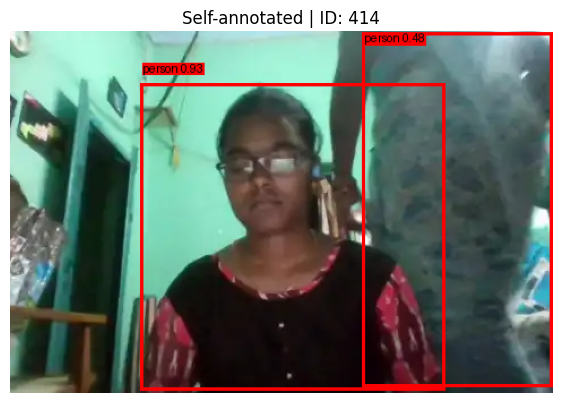

ID: 428
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


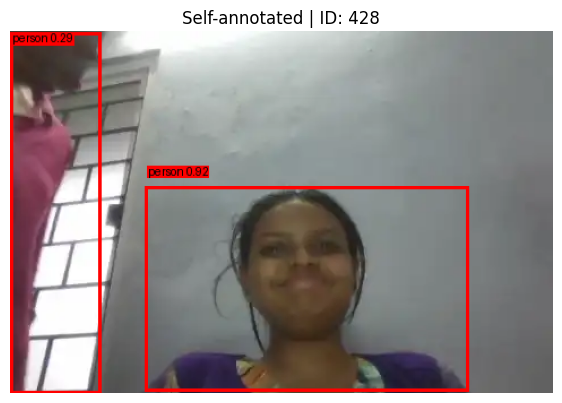

ID: 456
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


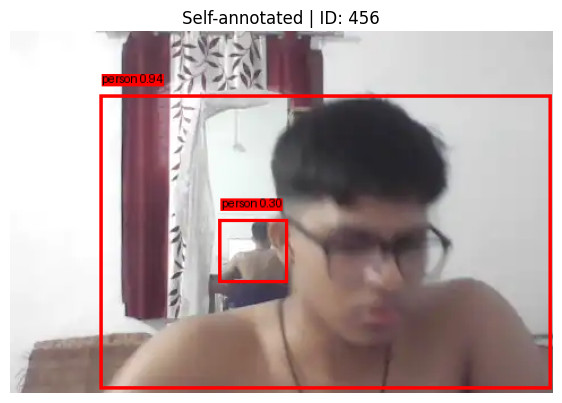

ID: 459
Status: auto_annotated
Final counts: {'person': 1, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


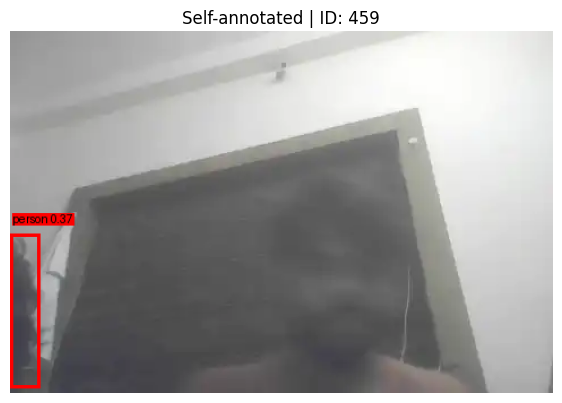

ID: 483
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


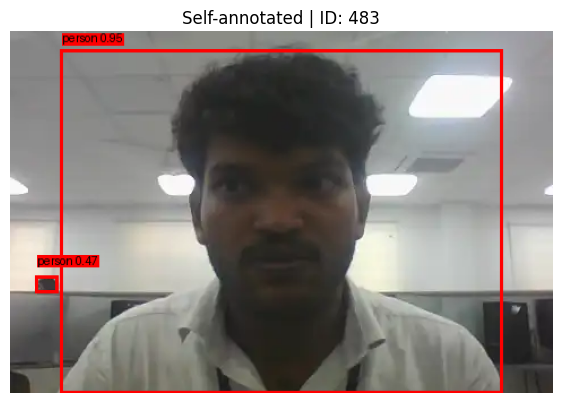

ID: 499
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolov8n
Phone model: yolo26


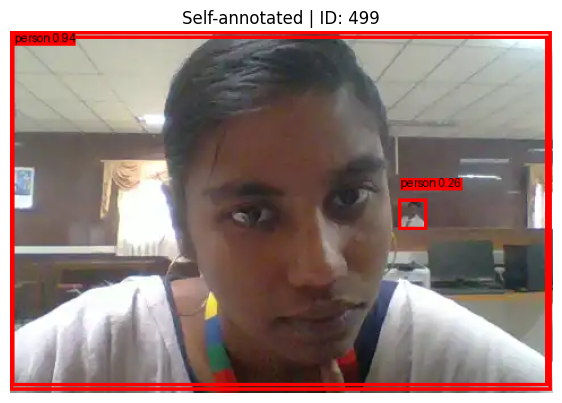

ID: 526
Status: auto_annotated
Final counts: {'person': 4, 'laptop': 0, 'cellphone': 0}
Person model: yolo_world
Laptop model: yolo26
Phone model: yolo26


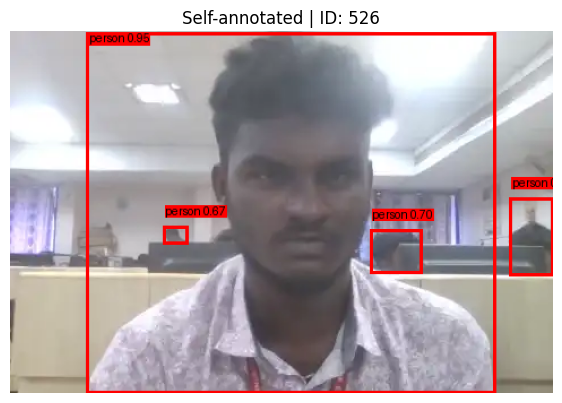

ID: 527
Status: auto_annotated
Final counts: {'person': 3, 'laptop': 0, 'cellphone': 0}
Person model: yolo_world
Laptop model: yolo26
Phone model: yolo26


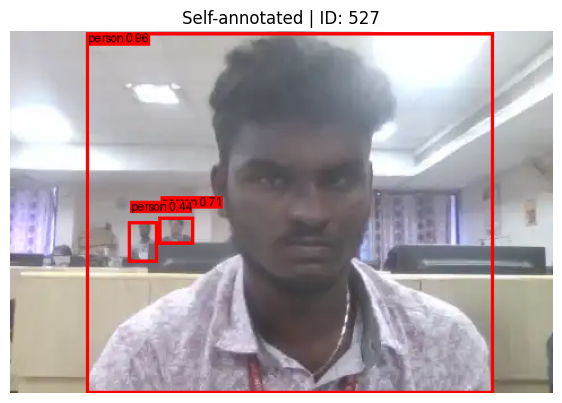

ID: 529
Status: auto_annotated
Final counts: {'person': 3, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


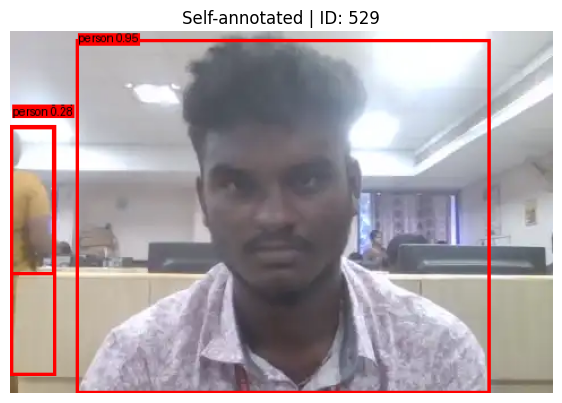

ID: 535
Status: auto_annotated
Final counts: {'person': 3, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


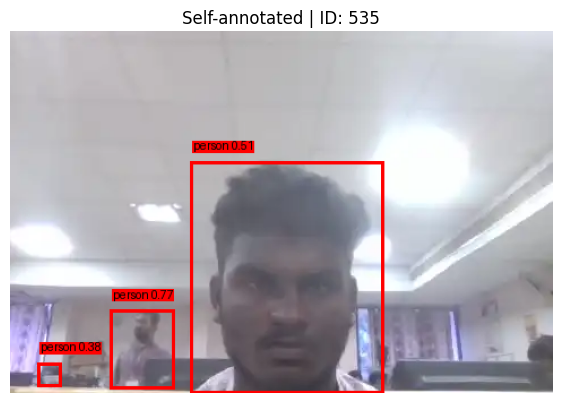

ID: 539
Status: auto_annotated
Final counts: {'person': 4, 'laptop': 0, 'cellphone': 0}
Person model: yolov8n
Laptop model: yolo26
Phone model: yolo26


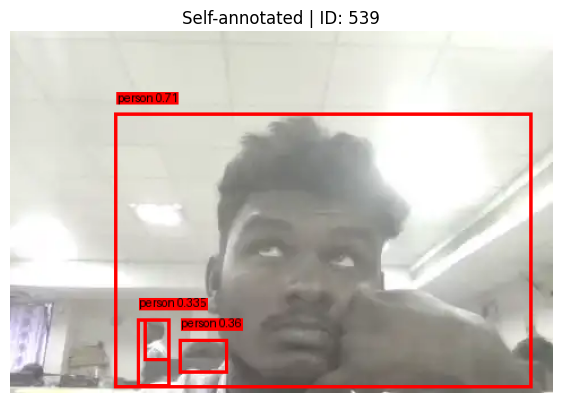

ID: 540
Status: auto_annotated
Final counts: {'person': 3, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


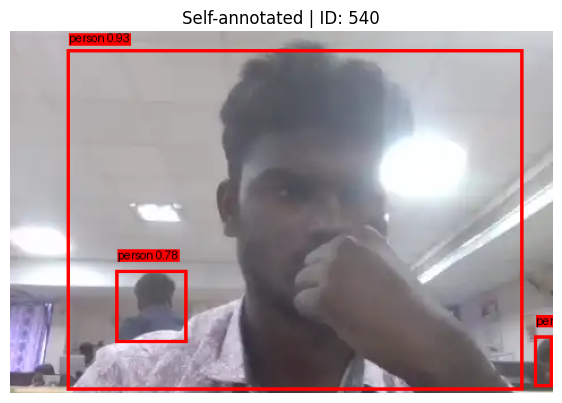

ID: 552
Status: auto_annotated
Final counts: {'person': 4, 'laptop': 0, 'cellphone': 0}
Person model: yolo_world
Laptop model: yolo26
Phone model: yolo26


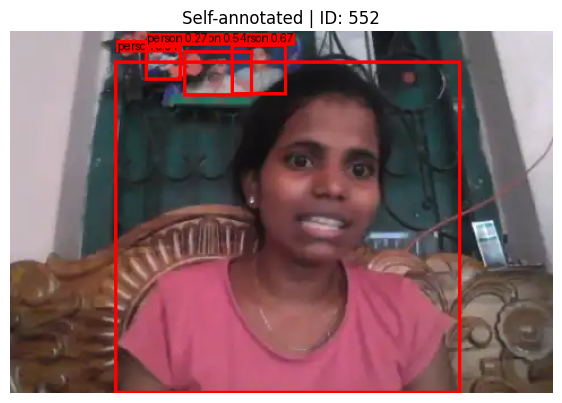

ID: 553
Status: auto_annotated
Final counts: {'person': 3, 'laptop': 0, 'cellphone': 0}
Person model: yolo_world
Laptop model: yolo26
Phone model: yolo26


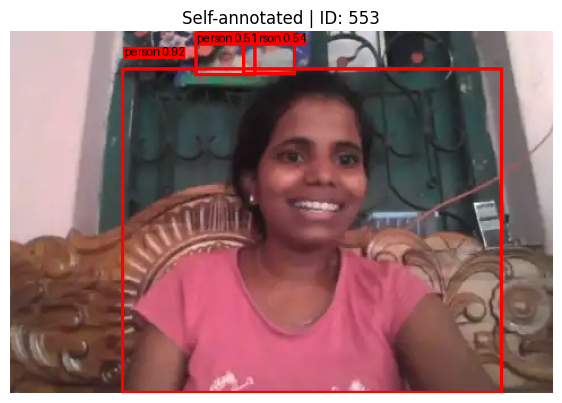

ID: 571
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


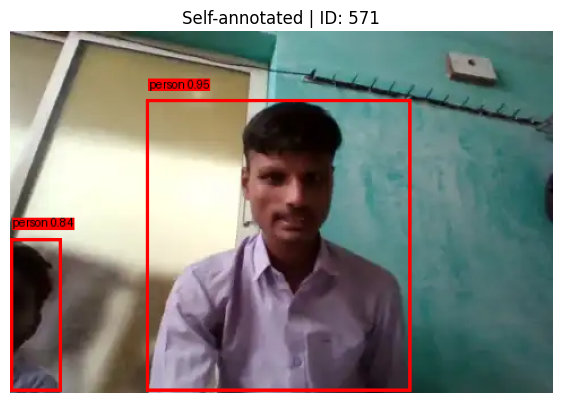

ID: 576
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


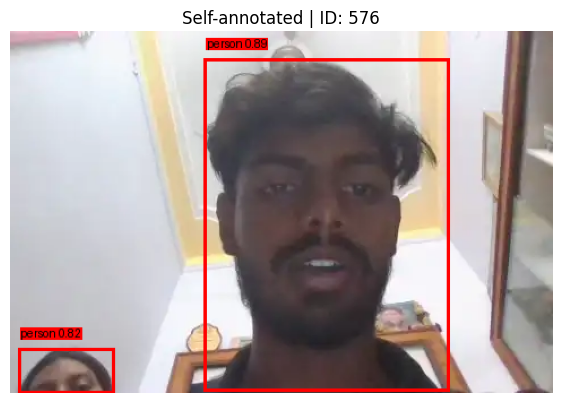

ID: 580
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolov8n
Laptop model: yolo26
Phone model: yolo26


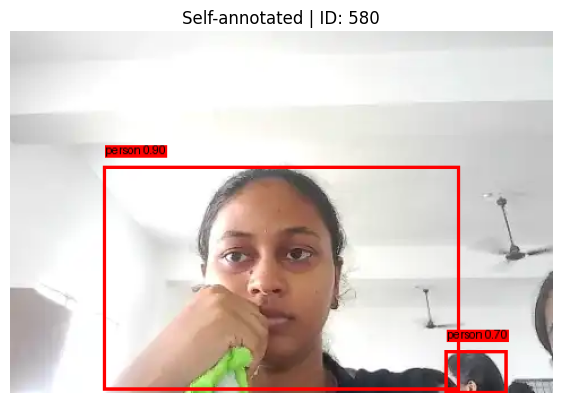

ID: 581
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolov8n
Laptop model: yolo26
Phone model: yolo26


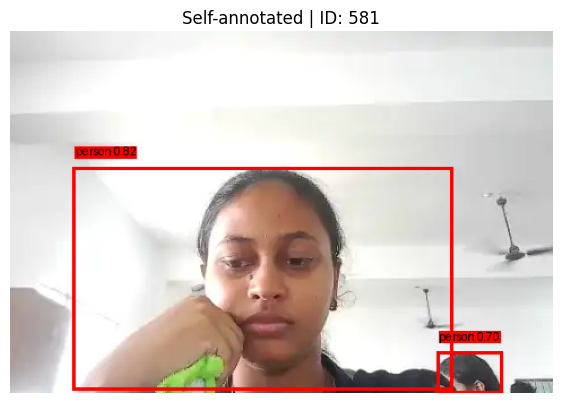

ID: 586
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


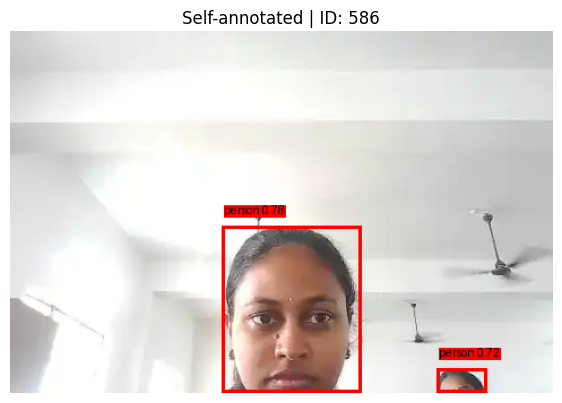

ID: 591
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


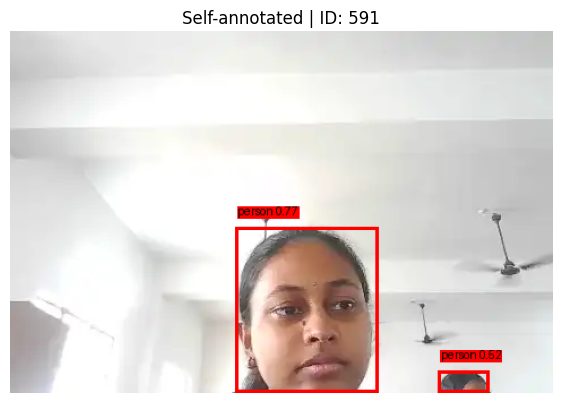

ID: 593
Status: auto_annotated
Final counts: {'person': 3, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


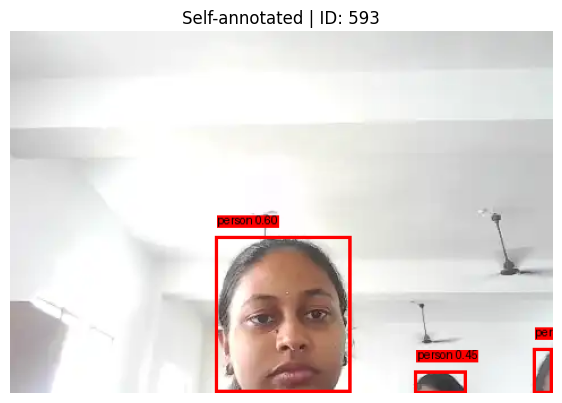

ID: 594
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


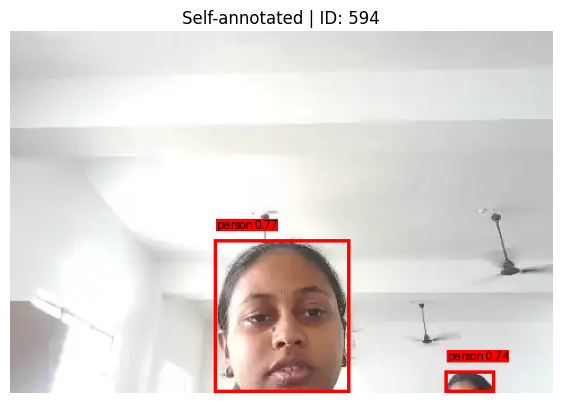

ID: 605
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


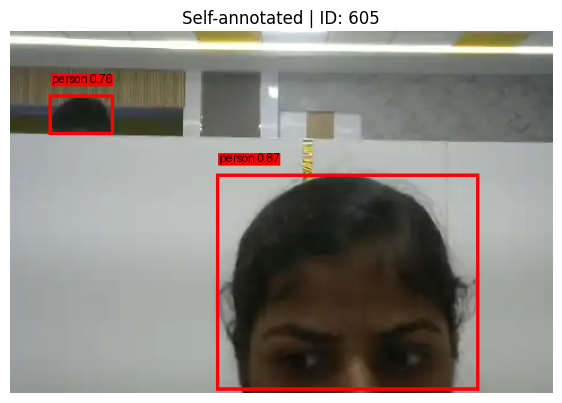

ID: 606
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


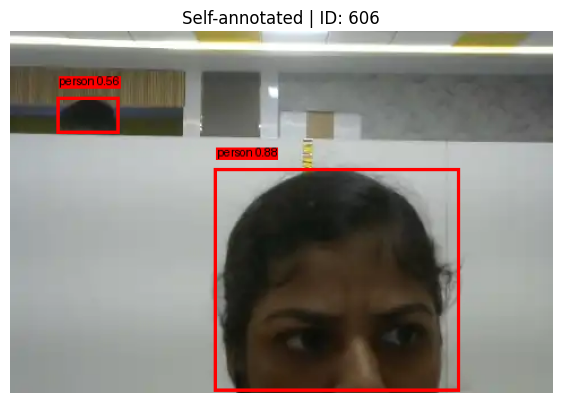

ID: 607
Status: auto_annotated
Final counts: {'person': 2, 'laptop': 0, 'cellphone': 0}
Person model: yolo26
Laptop model: yolo26
Phone model: yolo26


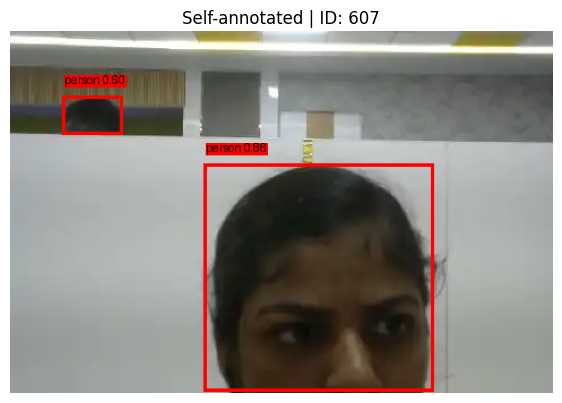

KeyboardInterrupt: Interrupted by user

In [ ]:
# =========================
# SHOW SELF-ANNOTATED IMAGES WITH ANNOTATIONS
# =========================

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

log_df = pd.read_csv("output_log.csv")

print("Columns:")
print(log_df.columns.tolist())

# self annotated = not sent for review
self_annotated_df = log_df[log_df["status"] != "review_needed"].copy()

print("Self-annotated images:", len(self_annotated_df))

# Show all in batches
batch_size = 25

for start in range(0, len(self_annotated_df), batch_size):
    end = min(start + batch_size, len(self_annotated_df))
    batch = self_annotated_df.iloc[start:end]

    print("\n" + "=" * 100)
    print(f"SELF-ANNOTATED IMAGES {start + 1} to {end}")
    print("=" * 100)

    for _, row in batch.iterrows():
        print("ID:", row.get("id"))
        print("Status:", row.get("status"))

        if "final_counts" in row:
            print("Final counts:", row.get("final_counts"))

        if "best_person_model" in row:
            print("Person model:", row.get("best_person_model"))

        if "best_laptop_model" in row:
            print("Laptop model:", row.get("best_laptop_model"))

        if "best_cellphone_model" in row:
            print("Phone model:", row.get("best_cellphone_model"))

        viz_path = row.get("visualization_path")

        if isinstance(viz_path, str) and os.path.exists(viz_path):
            img = Image.open(viz_path).convert("RGB")

            plt.figure(figsize=(7, 5))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"Self-annotated | ID: {row.get('id')}")
            plt.show()
        else:
            print("Visualization not found:", viz_path)

    input("Press Enter to show next batch...")

Cell started
CSV loaded. Rows: 116
Total review_needed: 47

ID: 409
REVIEW REASON: person_fail
GROUND TRUTH: {'person': 1, 'laptop': 0, 'cellphone': 0}
PREDICTED: {'person': None, 'laptop': 0, 'cellphone': 0}
Visualization path: visualized_predictions/review_needed/per_class_yolo_selection/409_per_class_yolo_selection.png


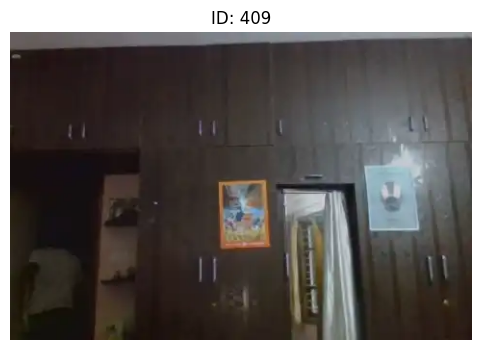


ID: 410
REVIEW REASON: person_fail; phone_fail
GROUND TRUTH: {'person': 1, 'laptop': 0, 'cellphone': 1}
PREDICTED: {'person': None, 'laptop': 0, 'cellphone': None}
Visualization path: visualized_predictions/review_needed/per_class_yolo_selection/410_per_class_yolo_selection.png


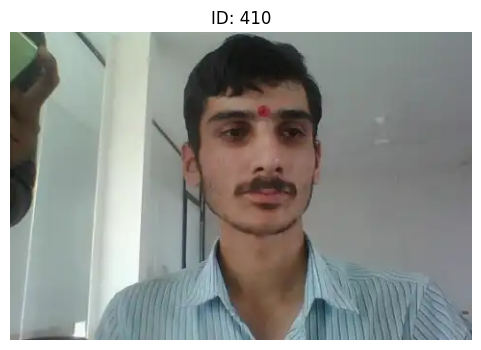


ID: 417
REVIEW REASON: person_fail
GROUND TRUTH: {'person': 2, 'laptop': 0, 'cellphone': 0}
PREDICTED: {'person': None, 'laptop': 0, 'cellphone': 0}
Visualization path: visualized_predictions/review_needed/per_class_yolo_selection/417_per_class_yolo_selection.png


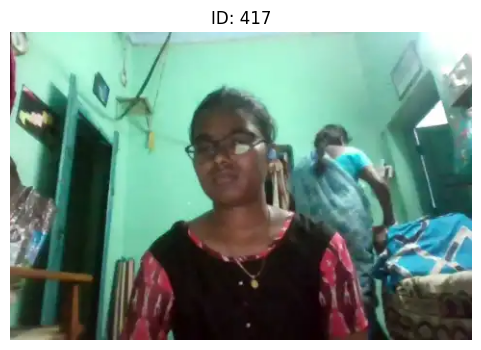


ID: 419
REVIEW REASON: person_fail; phone_fail
GROUND TRUTH: {'person': 2, 'laptop': 0, 'cellphone': 1}
PREDICTED: {'person': None, 'laptop': 0, 'cellphone': None}
Visualization path: visualized_predictions/review_needed/per_class_yolo_selection/419_per_class_yolo_selection.png


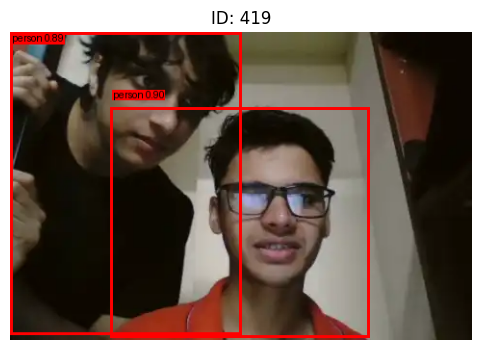


ID: 441
REVIEW REASON: person_fail
GROUND TRUTH: {'person': 1, 'laptop': 0, 'cellphone': 0}
PREDICTED: {'person': None, 'laptop': 0, 'cellphone': 0}
Visualization path: visualized_predictions/review_needed/per_class_yolo_selection/441_per_class_yolo_selection.png


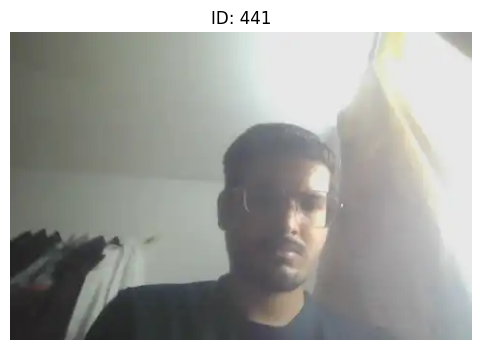


ID: 449
REVIEW REASON: person_fail
GROUND TRUTH: {'person': 1, 'laptop': 0, 'cellphone': 0}
PREDICTED: {'person': None, 'laptop': 0, 'cellphone': 0}
Visualization path: visualized_predictions/review_needed/per_class_yolo_selection/449_per_class_yolo_selection.png


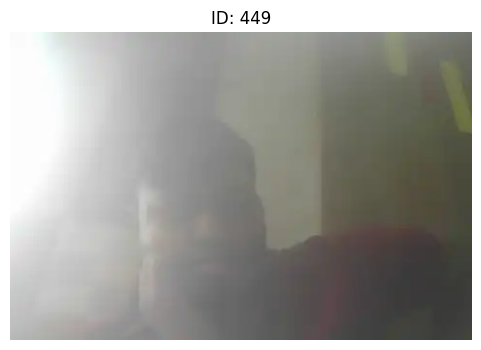


ID: 451
REVIEW REASON: person_fail
GROUND TRUTH: {'person': 1, 'laptop': 0, 'cellphone': 0}
PREDICTED: {'person': None, 'laptop': 0, 'cellphone': 0}
Visualization path: visualized_predictions/review_needed/per_class_yolo_selection/451_per_class_yolo_selection.png


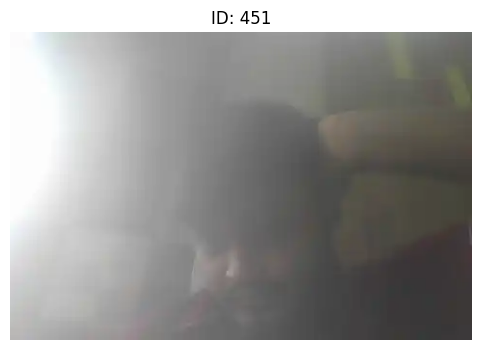


ID: 453
REVIEW REASON: person_fail
GROUND TRUTH: {'person': 0, 'laptop': 0, 'cellphone': 0}
PREDICTED: {'person': None, 'laptop': 0, 'cellphone': 0}
Visualization path: visualized_predictions/review_needed/per_class_yolo_selection/453_per_class_yolo_selection.png


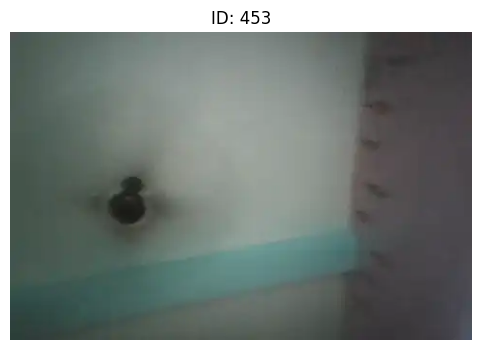


ID: 458
REVIEW REASON: person_fail
GROUND TRUTH: {'person': 1, 'laptop': 0, 'cellphone': 0}
PREDICTED: {'person': None, 'laptop': 0, 'cellphone': 0}
Visualization path: visualized_predictions/review_needed/per_class_yolo_selection/458_per_class_yolo_selection.png


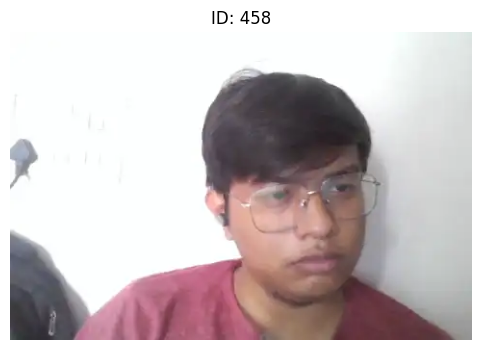


ID: 477
REVIEW REASON: person_fail; phone_fail
GROUND TRUTH: {'person': 3, 'laptop': 0, 'cellphone': 1}
PREDICTED: {'person': None, 'laptop': 0, 'cellphone': None}
Visualization path: visualized_predictions/review_needed/per_class_yolo_selection/477_per_class_yolo_selection.png


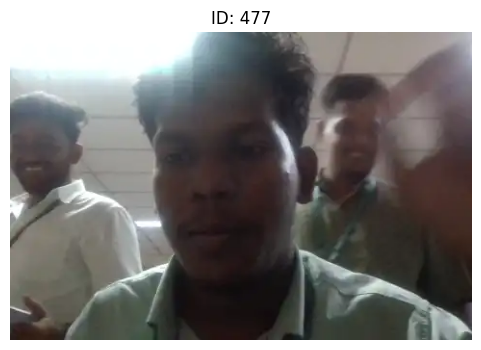

Done


In [ ]:
# =========================
# FAST CHECK: REVIEW IMAGES WITH DETAILS
# =========================

print("Cell started", flush=True)

log_df = pd.read_csv("output_log.csv")
print("CSV loaded. Rows:", len(log_df), flush=True)

review_df = log_df[log_df["status"] == "review_needed"].copy()
print("Total review_needed:", len(review_df), flush=True)

# Show only first 10 first
review_df = review_df.head(10)

for idx, row in review_df.iterrows():
    print("\n" + "="*80, flush=True)
    print("ID:", row.get("id"), flush=True)

    reasons = []
    if bool(row.get("person_review_needed")):
        reasons.append("person_fail")
    if bool(row.get("laptop_review_needed")):
        reasons.append("laptop_fail")
    if bool(row.get("cellphone_review_needed")):
        reasons.append("phone_fail")

    print("REVIEW REASON:", "; ".join(reasons), flush=True)
    print("GROUND TRUTH:", row.get("ground_truth"), flush=True)
    print("PREDICTED:", row.get("final_counts"), flush=True)

    viz_path = row.get("visualization_path")
    print("Visualization path:", viz_path, flush=True)

    if isinstance(viz_path, str) and os.path.exists(viz_path):
        img = Image.open(viz_path).convert("RGB")
        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"ID: {row.get('id')}")
        plt.show()
        plt.close()
    else:
        print("Visualization not found", flush=True)

print("Done", flush=True)

In [ ]:
# =========================
# DOWNLOAD OUTPUT FILES
# =========================
# Gemini comparison has been removed.
# This notebook now uses only YOLO models + ground truth for per-class annotation selection.

print("Main output CSV:", LOG_CSV_PATH)
print("Main output JSON:", LOG_JSON_PATH)

# Uncomment in Colab if you want to download the CSV directly:
# files.download(str(LOG_CSV_PATH))
